# Harness de contingencia y saturación — ATU resolver

Banco de pruebas del corredor: simula **colas y saturación por estación** bajo un plan de despacho e
**inyecta incidentes** para comprobar que un re-plan de contingencia **evita el colapso**. Las
decisiones de diseño y su justificación están en `engine/simulation/README.md`.

Recorrido: (1) red + perfil de demanda → (2) plan base del optimizador → (3) día normal acotado →
(4) incidente que **colapsa** la red bajo el plan base → (5) re-plan de contingencia que **recupera**.

In [1]:
import sys
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "engine").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from engine.network import topology
from engine.optimizer import milp
from engine.simulation import (RedConfig, PerfilDemanda, Modificadores, simular_dia,
                               inject_transit_disruption, inject_external_event, resumen,
                               saturacion_max_por_estacion)

AHORA = datetime(2026, 6, 13, 8, 0, tzinfo=timezone.utc)
HORAS_OP = range(5, 23)
print("Estaciones:", topology.N_ESTACIONES, "| Servicios:", [s.codigo for s in topology.SERVICIOS])

Estaciones: 45 | Servicios: ['REG', 'EXP_A', 'EXP_B']


## 1. Red y perfil de demanda

`RedConfig` fija el **aforo** por rol de estación (terminal/hub/regular). `PerfilDemanda.sintetico`
genera llegadas **bimodales** (pico mañana y tarde) y destinos **direccionales** (mañana → centro,
tarde → periferia) — corrige el pico único y los destinos uniformes del generador de trip chaining.

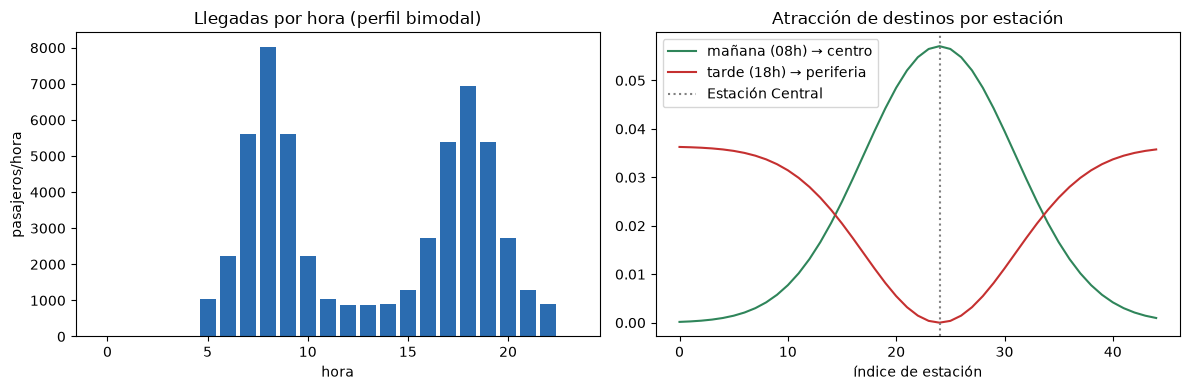

Aforo por rol: [500.0, 1000.0, 2000.0]


In [2]:
cfg = RedConfig.por_defecto()
perfil = PerfilDemanda.sintetico("laboral", pico_llegadas=500.0)

llegadas_hora = perfil.lam.sum(axis=1)        # total de llegadas/hora en la red
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(24), llegadas_hora, color="#2b6cb0")
axes[0].set_title("Llegadas por hora (perfil bimodal)"); axes[0].set_xlabel("hora")
axes[0].set_ylabel("pasajeros/hora")

# Direccionalidad: atracción media de destinos en la mañana vs. la tarde.
axes[1].plot(perfil.P[8].mean(axis=0), label="mañana (08h) → centro", color="#2f855a")
axes[1].plot(perfil.P[18].mean(axis=0), label="tarde (18h) → periferia", color="#c53030")
axes[1].axvline(topology.INDICE_ESTACION[topology.TERMINAL_CENTRAL], ls=":", color="gray",
                label="Estación Central")
axes[1].set_title("Atracción de destinos por estación"); axes[1].set_xlabel("índice de estación")
axes[1].legend()
plt.tight_layout(); plt.show()

print("Aforo por rol:", sorted(set(cfg.aforo.tolist())))

## 2. Plan base por hora (optimizador)

Se resuelve el MILP para la OD esperada de cada hora (`perfil.od_hora(h)`). El plan sigue el pico:
más buses cuando hay más demanda. Este es el plan "pico-consciente" que en producción vendría
precalculado y servido en O(1).

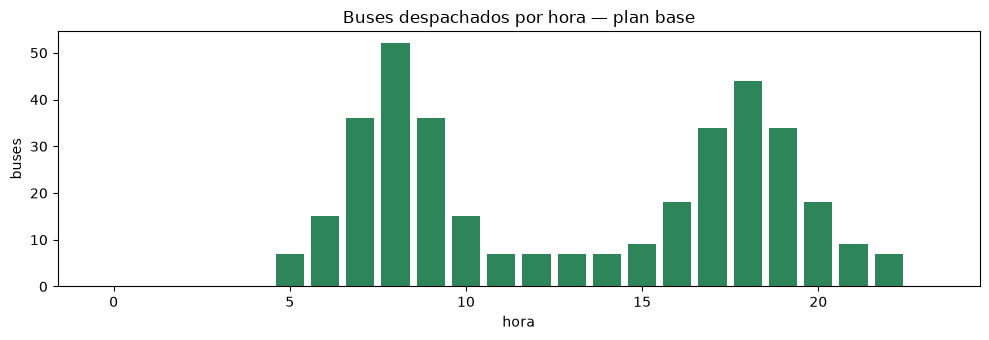

In [3]:
restr = milp.RestriccionesFlota(flota_total=120, conductores_disponibles=140,
                                capacidad_bus=160, max_despachos=40)
plan_base = {h: milp.resolver_despacho(AHORA, perfil.od_hora(h), restr, 0.0) for h in HORAS_OP}

buses_hora = [sum(d.num_buses for d in plan_base[h].despachos) if h in plan_base else 0
              for h in range(24)]
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(range(24), buses_hora, color="#2f855a")
ax.set_title("Buses despachados por hora — plan base"); ax.set_xlabel("hora")
ax.set_ylabel("buses"); plt.tight_layout(); plt.show()

## 3. Día normal — la saturación se mantiene acotada

Simulamos el día (pasos de 5 min, consolidado a hora) bajo el plan base, sin incidentes. La
saturación máxima se mantiene **por debajo de 1** (la cola no supera el aforo): no hay colapso.

In [4]:
res_normal = simular_dia(perfil, plan_base, cfg, seed=1)
print("NORMAL:", resumen(res_normal))

NORMAL: {'saturacion_max': 0.8257542087542087, 'estacion_mas_saturada': 'Terminal Matellini', 'cola_pico': 1651.5084175084173, 'pasajeros_hora_espera': 78494.17508417508, 'colapso': False, 'n_eventos_colapso': 0}


## 4. Incidente — colapso bajo el plan base

Inyectamos una disrupción severa en **Estación Central** (hub central): 85% de pérdida de capacidad
de 08:00 a 11:00, con **represamiento** a las estaciones vecinas. Con el plan base, la red
**colapsa** (saturación > 100%).

In [5]:
CENTRAL = topology.TERMINAL_CENTRAL
mods = inject_transit_disruption(Modificadores.vacio(), CENTRAL,
                                 hora_inicio=8, duracion_h=3, reduccion_pct=85.0)
res_disrupt = simular_dia(perfil, plan_base, cfg, mods=mods, seed=1)
print("DISRUPCIÓN (plan base):", resumen(res_disrupt))

DISRUPCIÓN (plan base): {'saturacion_max': 1.082542760942762, 'estacion_mas_saturada': 'Estación Central', 'cola_pico': 2164.1797979798002, 'pasajeros_hora_espera': 91533.05420875418, 'colapso': True, 'n_eventos_colapso': 5}


## 5. Re-plan de contingencia — recuperación

Conocida la incidencia, el optimizador **re-planifica las horas afectadas** (y dos horas después)
sabiendo la pérdida de capacidad: surge frecuencia para compensar. El mismo incidente, bajo el plan
de contingencia, **no colapsa** y reduce drásticamente la espera acumulada.

In [6]:
inc = [milp.IncidenciaOperativa(estacion=CENTRAL, capacidad_reducida_pct=85.0)]
plan_cont = dict(plan_base)
for h in (8, 9, 10, 11, 12):
    plan_cont[h] = milp.resolver_despacho(AHORA, perfil.od_hora(h), restr, 0.0, incidencias=inc)
res_cont = simular_dia(perfil, plan_cont, cfg, mods=mods, seed=1)
print("CONTINGENCIA:", resumen(res_cont))

tabla = pd.DataFrame([resumen(res_normal), resumen(res_disrupt), resumen(res_cont)],
                     index=["normal", "disrupción (base)", "contingencia"])
print()
print(tabla[["saturacion_max", "cola_pico", "pasajeros_hora_espera", "colapso", "n_eventos_colapso"]])
ahorro = 100 * (resumen(res_disrupt)["pasajeros_hora_espera"]
                - resumen(res_cont)["pasajeros_hora_espera"]) / resumen(res_disrupt)["pasajeros_hora_espera"]
print(f"\nLa contingencia reduce la espera acumulada en {ahorro:.0f}% frente a no reaccionar.")

CONTINGENCIA: {'saturacion_max': 0.735181144781145, 'estacion_mas_saturada': 'Estación Central', 'cola_pico': 1469.456565656566, 'pasajeros_hora_espera': 38987.486195286205, 'colapso': False, 'n_eventos_colapso': 0}

                   saturacion_max    cola_pico  pasajeros_hora_espera  \
normal                   0.825754  1651.508418           78494.175084   
disrupción (base)        1.082543  2164.179798           91533.054209   
contingencia             0.735181  1469.456566           38987.486195   

                   colapso  n_eventos_colapso  
normal               False                  0  
disrupción (base)     True                  5  
contingencia         False                  0  

La contingencia reduce la espera acumulada en 57% frente a no reaccionar.


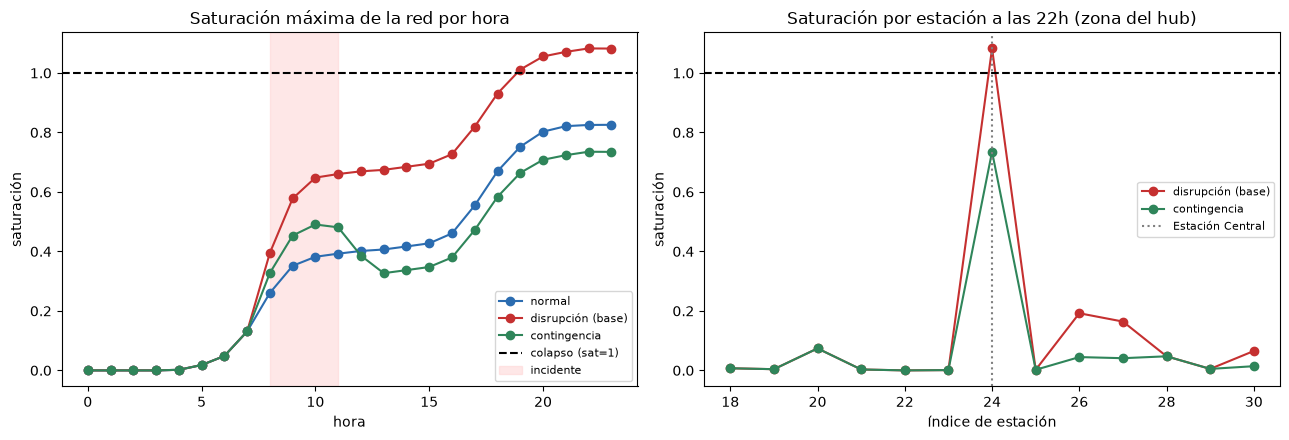

In [7]:
# Saturación máxima por hora en los tres escenarios.
def sat_por_hora(res):
    return res.saturacion.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for res, lab, col in [(res_normal, "normal", "#2b6cb0"),
                      (res_disrupt, "disrupción (base)", "#c53030"),
                      (res_cont, "contingencia", "#2f855a")]:
    axes[0].plot(range(24), sat_por_hora(res), "o-", label=lab, color=col)
axes[0].axhline(1.0, ls="--", color="black", label="colapso (sat=1)")
axes[0].axvspan(8, 11, color="#fed7d7", alpha=0.6, label="incidente")
axes[0].set_title("Saturación máxima de la red por hora"); axes[0].set_xlabel("hora")
axes[0].set_ylabel("saturación"); axes[0].legend(fontsize=8)

# Saturación por estación en la peor hora del incidente (represamiento alrededor del hub).
hpeor = int(sat_por_hora(res_disrupt).argmax())
ci = topology.INDICE_ESTACION[CENTRAL]
rango = range(max(0, ci - 6), min(topology.N_ESTACIONES, ci + 7))
x = list(rango)
axes[1].plot(x, res_disrupt.saturacion[hpeor][list(rango)], "o-", color="#c53030",
             label="disrupción (base)")
axes[1].plot(x, res_cont.saturacion[hpeor][list(rango)], "o-", color="#2f855a",
             label="contingencia")
axes[1].axhline(1.0, ls="--", color="black")
axes[1].axvline(ci, ls=":", color="gray", label="Estación Central")
axes[1].set_title(f"Saturación por estación a las {hpeor:02d}h (zona del hub)")
axes[1].set_xlabel("índice de estación"); axes[1].set_ylabel("saturación"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6. Evento exógeno (bonus)

`inject_external_event` modela un pico masivo (concierto/partido): un salto de llegadas concentrado
en una estación. Útil para entrenar la respuesta ante demanda exógena, no recurrente.

In [8]:
mods_evt = inject_external_event(Modificadores.vacio(), "Estadio Nacional",
                                 hora_evento=20, afluencia=8000, inbound=False)
res_evt = simular_dia(perfil, plan_base, cfg, mods=mods_evt, seed=1)
print("EVENTO en Estadio Nacional (salida 20h):", resumen(res_evt))

EVENTO en Estadio Nacional (salida 20h): {'saturacion_max': 15.696444444444449, 'estacion_mas_saturada': 'Estadio Nacional', 'cola_pico': 7848.222222222224, 'pasajeros_hora_espera': 109930.46127946128, 'colapso': True, 'n_eventos_colapso': 4}


## 7. Cierre — listo para datos reales

El harness mide lo que los datos reales **no** observan (cola/saturación son latentes con cobro
abierto) y valida que el plan base + contingencia evitan el colapso. Cuando lleguen los CSV por
tarjeta, el perfil se construye del **mismo tensor Mbase intradía** con
`PerfilDemanda.desde_mbase_intradia(tensor_24xNxN)` —sin tocar el resto del harness—, y todo este
banco de pruebas aplica directamente sobre la demanda real.